In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
sales = pd.read_csv(r"D:\task_1\business_sales_dataset.csv")

In [ ]:
sales.head()

,Order ID,Order Date,Customer Name,Region,State,Category,Product Name,Quantity,Sales,Profit,Discount
0,ORD00001,2024-07-12,Breanna Riley,North,Haryana,Office Supplies,Pen,5,1262.21,107.14,0.03
1,ORD00002,2024-07-28,Joseph Scott,West,Maharashtra,Technology,Monitor,1,513.79,55.57,0.18
2,ORD00003,2023-06-13,Kayla Houston,West,Maharashtra,Technology,Monitor,8,2966.87,748.71,0.00
3,ORD00004,2024-01-25,Dylan Harris,East,Odisha,Office Supplies,Paper,3,1115.80,268.77,0.03
4,ORD00005,2024-01-23,Michael Jackson,East,Bihar,Technology,Tablet,5,4045.28,940.26,0.16


In [11]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       1000 non-null   str    
 1   Order Date     1000 non-null   str    
 2   Customer Name  1000 non-null   str    
 3   Region         1000 non-null   str    
 4   State          1000 non-null   str    
 5   Category       1000 non-null   str    
 6   Product Name   1000 non-null   str    
 7   Quantity       1000 non-null   int64  
 8   Sales          1000 non-null   float64
 9   Profit         1000 non-null   float64
 10  Discount       1000 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 86.1 KB


In [12]:
sales.describe()

,Quantity,Sales,Profit,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.563000,2502.601650,441.610710,0.146990
std,2.887277,1410.289765,321.579397,0.087577
min,1.000000,50.460000,9.370000,0.000000
25%,3.000000,1299.677500,187.420000,0.070000
50%,6.000000,2452.125000,360.195000,0.150000
75%,8.000000,3711.167500,644.332500,0.220000
max,10.000000,4997.180000,1495.030000,0.300000


In [13]:
sales.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
State            0
Category         0
Product Name     0
Quantity         0
Sales            0
Profit           0
Discount         0
dtype: int64

In [14]:
sales = sales.dropna()

In [15]:
sales['Sales'] = sales['Sales'].fillna(sales['Sales'].mean())

In [16]:
sales.duplicated().sum()

np.int64(0)

In [17]:
sales = sales.drop_duplicates()

In [18]:
sales.dtypes


Order ID             str
Order Date           str
Customer Name        str
Region               str
State                str
Category             str
Product Name         str
Quantity           int64
Sales            float64
Profit           float64
Discount         float64
dtype: object

In [19]:
sales['Order Date'] = pd.to_datetime(sales['Order Date'])
sales[sales['Sales'] < 0]
sales[sales['Profit'] < 0]
sales = sales[sales['Sales'] > 0]

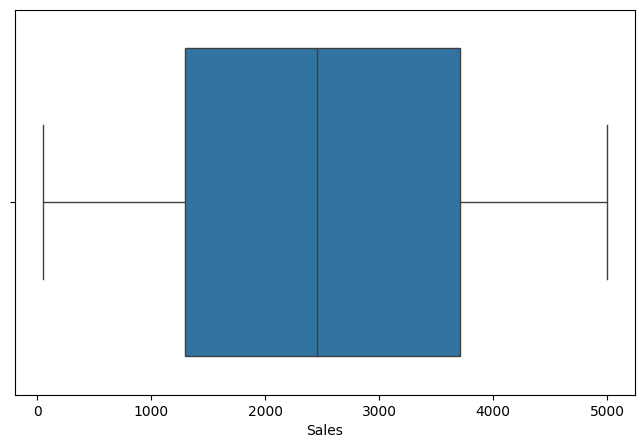

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=sales['Sales'])
plt.show()

In [21]:
Q1 = sales['Sales'].quantile(0.25)
Q3 = sales['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

sales = sales[(sales['Sales'] >= lower) & (sales['Sales'] <= upper)]

In [22]:
sales['Region'] = sales['Region'].str.title()

In [28]:
sales.to_csv("cleaned_sales_data.csv", index=False)

In [29]:
sales['Year'] = sales['Order Date'].dt.year
sales['Month'] = sales['Order Date'].dt.month_name()

In [30]:
monthly_sales = sales.groupby('Month')['Sales'].sum()

print(monthly_sales)

Month
April        209568.38
August       221804.50
December     187169.94
February     180132.67
January      201839.80
July         195939.54
June         212903.85
March        198970.73
May          184254.23
November     265209.51
October      274418.05
September    170390.45
Name: Sales, dtype: float64


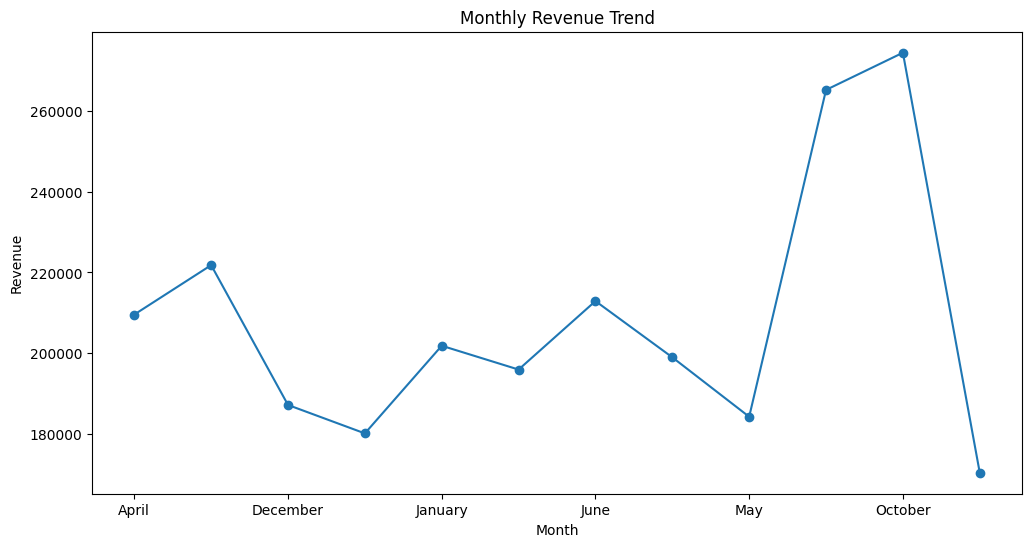

In [31]:
plt.figure(figsize=(12,6))

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [32]:
top_products = sales.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Bookcase    199484.53
Paper       198789.28
Pen         185700.89
Monitor     184538.16
Chair       183151.29
Marker      182444.45
Printer     176965.04
Tablet      167734.60
Sofa        164443.33
Stapler     156064.90
Name: Sales, dtype: float64
